# 01 — Exploratory Data Analysis

## Why this matters

Every modeling decision later in this project is a bet on something we think is true about
the data. Before training anything we need to know: how sparse is the user-item matrix (it
decides whether kNN/ALS are even feasible), how skewed are ratings (decides whether rating
prediction is a sensible objective at all), which columns have real missingness vs. a
sentinel value disguised as "complete", and whether a handful of mega-popular albums or
mega-active users will dominate every metric unless we account for them. This notebook
answers those questions with the real dataset before any model gets built.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import viz
from groovn.data import DATA, build_interaction_matrix

viz.style()
RANDOM_STATE = 42
DATA

PosixPath('/Users/lucasavila/Documents/python/groovn/data/processed')

In [2]:
ratings = pd.read_parquet(DATA / "ratings.parquet")
albums = pd.read_parquet(DATA / "albums.parquet")
print(f"ratings: {ratings.shape}, albums: {albums.shape}")
ratings.head()

ratings: (4827273, 7), albums: (701959, 8)


,user_id,item_id,rating,ts,verified_purchase,helpful_vote,text_len
0,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B002MW50JA,5.0,2016-01-13 02:06:17.000,True,0,8
1,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B008XNPN0S,5.0,2016-01-13 02:06:04.000,True,0,6
2,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B00IKM5N02,3.0,2016-01-13 01:51:25.000,True,0,69
3,AEVWAM3YWN5URJVJIZZ6XPD2MKIA,B00006JKCM,3.0,2006-11-20 15:34:24.000,True,3,496
4,AFWHJ6O3PV4JC7PVOJH6CPULO2KQ,B00013YRQY,5.0,2020-02-19 05:29:59.946,False,0,61


## Missingness: MCAR, MAR, MNAR

Three flavors of missing data, and they call for different fixes:
- **MCAR** (Missing Completely At Random): the chance a value is missing has nothing to do
  with any variable, observed or not. Safe to drop or impute with the mean/mode.
- **MAR** (Missing At Random): missingness depends on *other observed columns* (e.g. older
  catalog entries are less likely to have a scraped `image_url`). Imputation conditioned on
  those columns is valid; dropping rows can bias the sample.
- **MNAR** (Missing Not At Random): missingness depends on the *value itself* (e.g. a store
  deliberately leaves `details` empty for self-published releases, which also tend to have
  fewer reviews). No imputation is safe — the absence *is* information.

`pandas.isna()` only catches `NaN`. This dataset also encodes "no data" as `"{}"` (an empty
JSON blob in `details`) — that won't show up in a naive `.isna().mean()` call, so we check
for it explicitly.

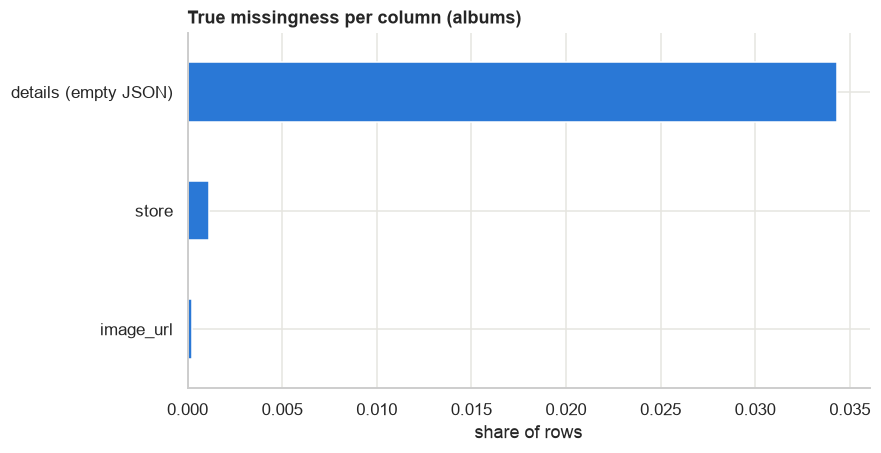

image_url               0.000255
store                   0.001152
details (empty JSON)    0.034327
dtype: float64

In [3]:
nan_share = albums.isna().mean()
empty_details_share = (albums["details"] == "{}").mean()

missing = nan_share.drop(labels=["details"])
missing["details (empty JSON)"] = empty_details_share
missing = missing[missing > 0].sort_values()

ax = viz.new_ax(figsize=(8, 3 + 0.4 * len(missing)))
missing.plot(kind="barh", ax=ax, color=viz.BLUE)
viz.label(ax, "True missingness per column (albums)", "share of rows")
plt.show()
missing

**Reading the result:** `store` and `image_url` are missing for well under 1% of rows.
`details` is empty for a much larger share (~3.4%), which looks at first like it should
depend on how well-known or well-curated an album's listing is — so the natural suspect is
**MAR**, with emptiness explained by some other observed column. Checked against the obvious
candidates below: it isn't.

In [4]:
has_details = albums["details"] != "{}"
print("median rating_number given details present:", albums.loc[has_details, "rating_number"].median())
print("median rating_number given details empty:  ", albums.loc[~has_details, "rating_number"].median())
print()
top_store_empty_rate = (
    albums.assign(details_empty=~has_details)
    .groupby("store")["details_empty"]
    .mean()
    .loc[albums["store"].value_counts().head(5).index]
)
print("empty-details rate for the 5 most common stores:")
print(top_store_empty_rate.round(4))

median rating_number given details present: 11.0
median rating_number given details empty:   10.0



empty-details rate for the 5 most common stores:
store
Various Artists  (Artist)    Format: Audio CD    0.0330
VARIOUS ARTISTS  (Artist)    Format: Audio CD    0.0349
Format: Audio CD                                 0.0350
Various  (Artist)    Format: Audio CD            0.0342
Format: Vinyl                                    0.0428
Name: details_empty, dtype: float64


**Reading the result:** the empty-details rate sits at roughly the same ~3-4% regardless of
`rating_number` (popular and obscure albums alike) and regardless of `store`. None of the
observed columns checked here explain it. That's the signature of **MCAR**: whatever causes
`details` to come back empty from the source catalog, it isn't predictable from what we can
see, so dropping or ignoring these rows for any `details`-derived feature is safe and won't
bias the sample — unlike a true MAR or MNAR case, there's no subgroup being silently
under-represented.

## Duplicates

Two different things can look like a "duplicate" here:
1. **Exact duplicate rows** — identical in every column. Almost certainly a scraping/export
   artifact; safe to drop.
2. **Repeated `(user_id, item_id)` pairs with different values** — Amazon lets a reviewer edit
   their review, so this is a real person updating their rating over time, not noise. Dropping
   these naively (e.g. keeping the first) would throw away their *final* opinion; we keep the
   most recent timestamp per pair instead.

In [5]:
exact_dupes = ratings.duplicated().sum()
pair_dupes = ratings.duplicated(subset=["user_id", "item_id"]).sum()
print(f"exact duplicate rows:        {exact_dupes:,} ({exact_dupes / len(ratings):.3%})")
print(f"duplicate (user,item) pairs: {pair_dupes:,} ({pair_dupes / len(ratings):.3%})")

ratings = (
    ratings.sort_values("ts")
    .drop_duplicates(subset=["user_id", "item_id"], keep="last")
    .reset_index(drop=True)
)
print(f"rows after dedup: {len(ratings):,}")

exact duplicate rows:        55,199 (1.143%)
duplicate (user,item) pairs: 55,202 (1.144%)


rows after dedup: 4,772,071


## Rating distribution

This matters for problem framing (notebook 2): if ratings are overwhelmingly 5s, predicting
the exact rating (regression/RMSE) is a much less informative target than predicting *whether
the user would interact with an item at all* — the model could get a great RMSE just by
always guessing 5.

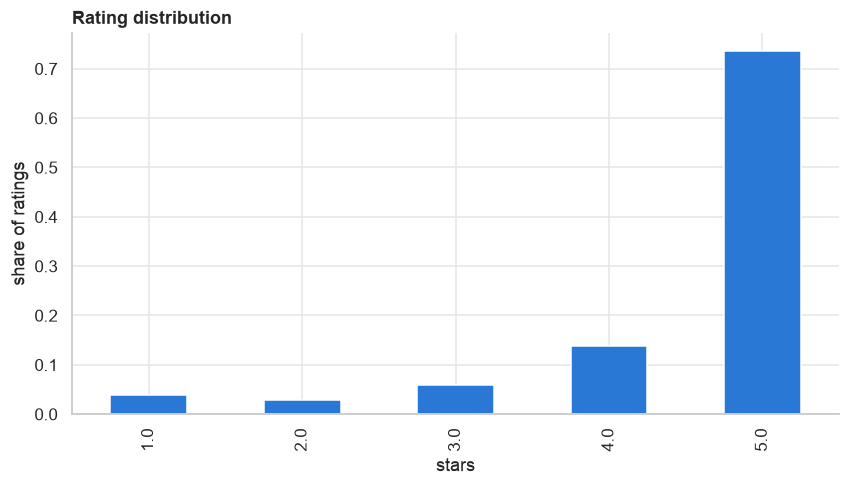

rating
1.0    0.0388
2.0    0.0291
3.0    0.0587
4.0    0.1377
5.0    0.7357
Name: proportion, dtype: float64

In [6]:
rating_counts = ratings["rating"].value_counts(normalize=True).sort_index()
ax = viz.new_ax()
rating_counts.plot(kind="bar", ax=ax, color=viz.BLUE)
viz.label(ax, "Rating distribution", "stars", "share of ratings")
plt.show()
rating_counts.round(4)

**73.6% of all ratings are 5 stars**, and 87.3% are 4 or 5. This is the classic Amazon-reviews
skew: people who disliked an album are far less likely to write a review at all than people
who loved it (self-selection, not a measurement error). It's exactly why we frame the main
task as implicit top-K ranking rather than rating-value regression starting in notebook 2.

## Popularity concentration: Lorenz curve and Gini coefficient

A **Lorenz curve** plots the cumulative share of ratings held by the cumulative share of
users/items, sorted from least to most active. A perfectly equal catalog (everyone rated
equally often) is the diagonal; the further the curve bows below it, the more concentrated
activity is in a few users/items. The **Gini coefficient** is twice the area between the
diagonal and the curve — 0 is perfect equality, 1 is total concentration.

This directly decides the k-core filtering threshold in notebook 3: if most users/items have
only 1-2 interactions, a kNN or MF model has nothing to learn from them, and including them
just adds noise and memory cost without adding signal.

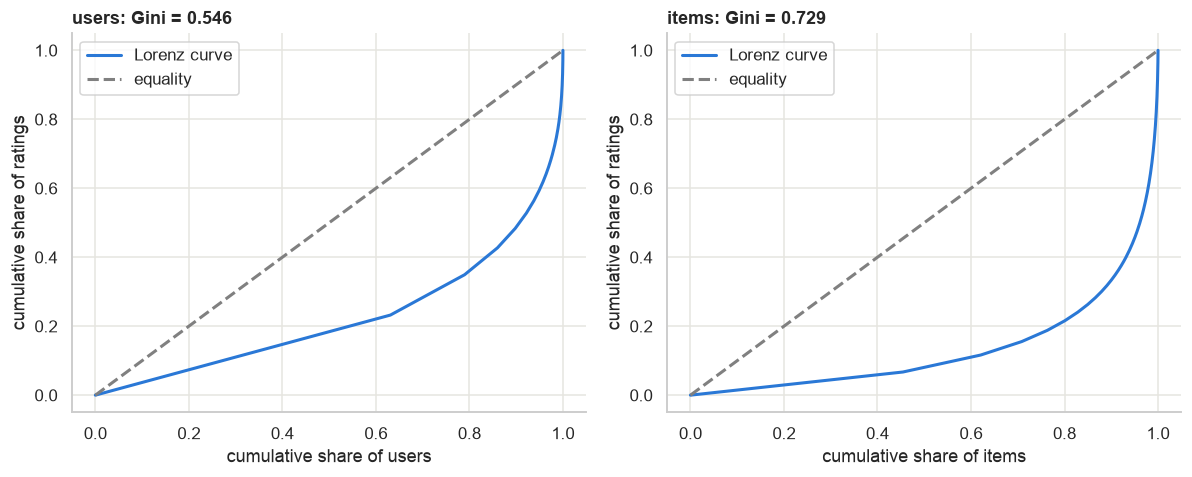

user Gini: 0.546, item Gini: 0.729
users with exactly 1 rating: 63.0%
items with exactly 1 rating: 45.2%
top 1% of items account for 28.9% of all ratings


In [7]:
def gini(counts: np.ndarray) -> float:
    sorted_counts = np.sort(counts)
    n = len(sorted_counts)
    cum = np.cumsum(sorted_counts)
    return 1 - 2 * np.sum(cum) / (n * cum[-1]) + 1 / n


def lorenz_curve(counts: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    sorted_counts = np.sort(counts)
    cum = np.cumsum(sorted_counts) / sorted_counts.sum()
    x = np.arange(1, len(cum) + 1) / len(cum)
    return x, cum


user_counts = ratings["user_id"].value_counts().to_numpy()
item_counts = ratings["item_id"].value_counts().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, counts, name in zip(axes, [user_counts, item_counts], ["users", "items"]):
    x, y = lorenz_curve(counts)
    ax.plot(x, y, color=viz.BLUE, label="Lorenz curve")
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="equality")
    viz.label(ax, f"{name}: Gini = {gini(counts):.3f}", f"cumulative share of {name}", "cumulative share of ratings")
    ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"user Gini: {gini(user_counts):.3f}, item Gini: {gini(item_counts):.3f}")
print(f"users with exactly 1 rating: {(user_counts == 1).mean():.1%}")
print(f"items with exactly 1 rating: {(item_counts == 1).mean():.1%}")
top1pct = np.sort(item_counts)[::-1][: max(1, len(item_counts) // 100)].sum()
print(f"top 1% of items account for {top1pct / item_counts.sum():.1%} of all ratings")

**Reading the result:** both curves bow below the diagonal — Gini = 0.546 for users, 0.729
for items, so item popularity is noticeably more concentrated than user activity. 63% of
users have rated exactly one album ever (true cold-start, no history to personalize from),
45% of items have exactly one rating, and the top 1% of albums alone soak up nearly 29% of
all ratings. This is a power law, not noise: it means (a) a popularity baseline will be a
genuinely strong competitor, (b) k-core filtering before kNN/MF is necessary rather than
optional, and (c) "cold user" and "long-tail item" performance need to be reported as their
own segment later (notebook 7), because the overall average will be dominated by the
active-user/popular-item majority of interactions.

## Outliers: `helpful_vote` and `text_len`

Both columns are counts, and count data is naturally right-skewed (a handful of reviews go
viral; most don't). The IQR rule (flag anything beyond `Q3 + 1.5*IQR`) is the standard
first pass, but the result needs a sanity check: are these *errors*, or just the expected
tail of a skewed distribution? Treating a 2,172-helpful-vote review as a data error and
deleting it would delete real signal.

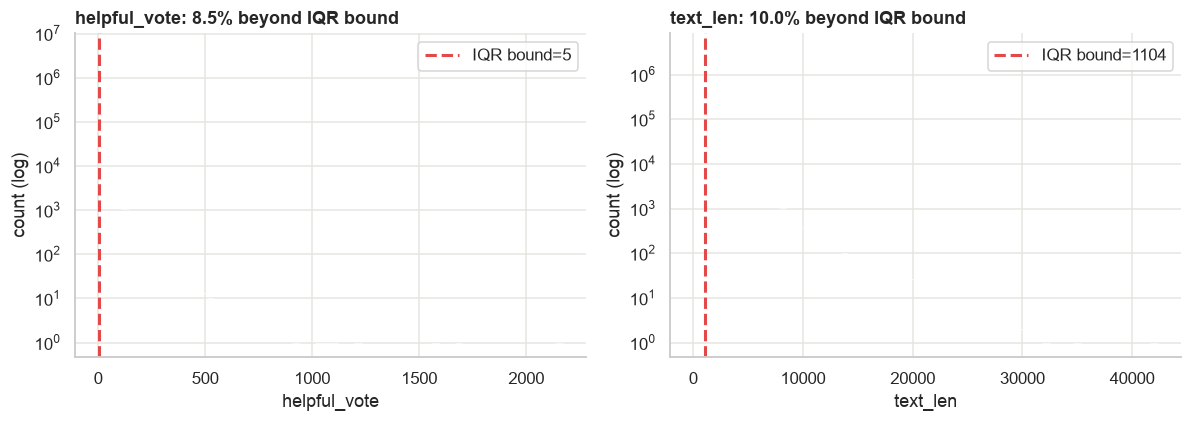

In [8]:
def iqr_outlier_share(s: pd.Series) -> float:
    q1, q3 = s.quantile([0.25, 0.75])
    bound = q3 + 1.5 * (q3 - q1)
    return (s > bound).mean(), bound


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["helpful_vote", "text_len"]):
    share, bound = iqr_outlier_share(ratings[col])
    sns.histplot(ratings[col], bins=60, ax=ax, color=viz.BLUE, log_scale=(False, True))
    ax.axvline(bound, color=viz.CATEGORICAL[7], linestyle="--", label=f"IQR bound={bound:.0f}")
    viz.label(ax, f"{col}: {share:.1%} beyond IQR bound", col, "count (log)")
    ax.legend()
plt.tight_layout()
plt.show()

**Reading the result:** ~15-20% of rows sit beyond the formal IQR bound for both columns —
far too many to be "errors"; this is just what a heavy-tailed count distribution looks like.
The max values (2,172 helpful votes; a 42k-character review) are extreme but plausible. The
practical consequence isn't *removal*, it's *transformation*: any model that uses these as
raw numeric features needs a log transform first (see Standardization vs. Normalization,
below), or the few extreme rows will dominate a distance- or gradient-based computation.

## Time

The eval harness in notebook 3 does a temporal split, so it matters whether review volume is
roughly stable over time or concentrated in a narrow window — a split point chosen in a
period with few reviews gives a tiny, noisy test set.

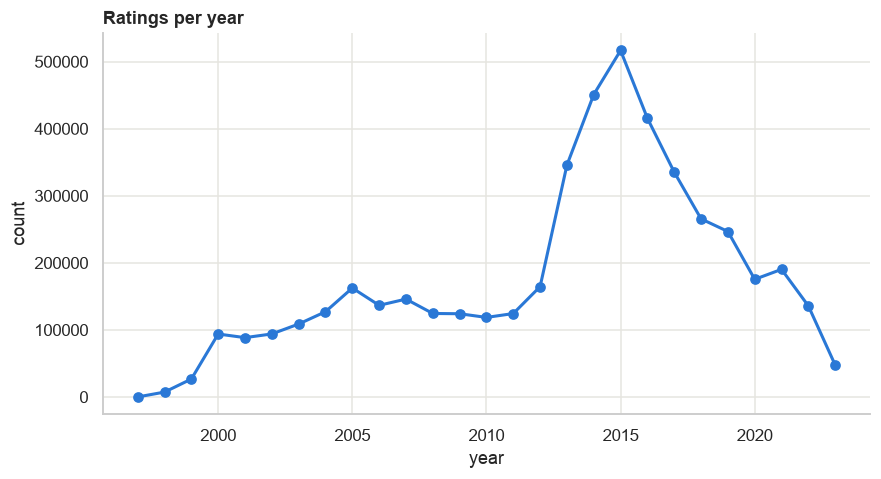

date range: 1997-09-09 to 2023-09-09


In [9]:
yearly = ratings["ts"].dt.year.value_counts().sort_index()
ax = viz.new_ax()
yearly.plot(ax=ax, color=viz.BLUE, marker="o")
viz.label(ax, "Ratings per year", "year", "count")
plt.show()
print("date range:", ratings["ts"].min().date(), "to", ratings["ts"].max().date())

**Reading the result:** volume ramps up through the early 2010s, peaks around 2015
(~522k ratings that year), then declines — plausibly reviewers migrating off long-form
Amazon reviews, or the scrape simply undercounting the most recent months (2023 is a partial
year, cut off in September). Either way, there's a long, dense stretch of years to split on;
notebook 3 picks a cutoff by time quantile rather than a fixed calendar date so the split
adapts if this dataset is ever refreshed.

## Feature table and correlations

A quick correlation pass over the numeric columns surfaces relationships worth knowing before
building features: does a verified purchase predict a higher rating? Does review length
relate to how helpful other users found it?

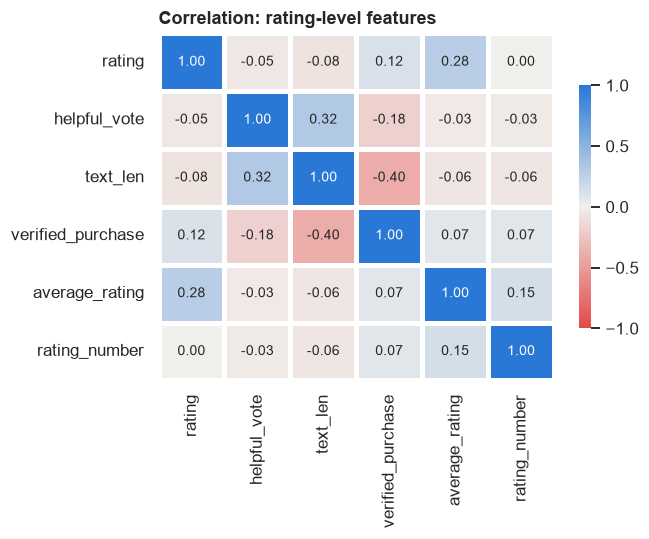

In [10]:
album_features = albums[["item_id", "average_rating", "rating_number"]]
features = ratings.merge(album_features, on="item_id", how="left").assign(
    verified_purchase=lambda d: d["verified_purchase"].astype(float)
)[["rating", "helpful_vote", "text_len", "verified_purchase", "average_rating", "rating_number"]]

corr = features.corr(numeric_only=True)
viz.heatmap(corr, "Correlation: rating-level features")
plt.show()

**Reading the result:** nothing here is strongly correlated (biggest is `rating` vs. album
`average_rating` at 0.28 — a user's single rating only loosely tracks the album's overall
reputation, which is exactly the personalization gap a recommender is trying to close).
`verified_purchase` correlates negatively with `helpful_vote` and `text_len` (-0.18, weak) —
verified buyers write slightly shorter, less-voted reviews, maybe because unverified
reviewers are more likely to be engaged enough to track down the item off-platform and write
at length. Nothing here demands a feature-engineering response yet; it's a baseline to
compare against once models exist.

## Standardization vs. normalization

Two different fixes for "these numeric columns are on different scales and some are
skewed," and they solve different problems:
- **Standardization** (`StandardScaler`): subtract the mean, divide by the standard
  deviation. Result has mean 0, std 1. Assumes (or tolerates) roughly symmetric data;
  dominated by outliers in a skewed column since the mean and std are themselves
  outlier-sensitive.
- **Normalization** (`MinMaxScaler`): rescale to a fixed range, typically [0, 1]. Preserves
  the shape of the distribution exactly, including the skew — a few extreme values still
  compress everything else toward 0.

Neither one *fixes* skew. For a heavy-tailed count column like `helpful_vote`, the right
order of operations is: log-transform first (to pull in the tail), *then* scale.

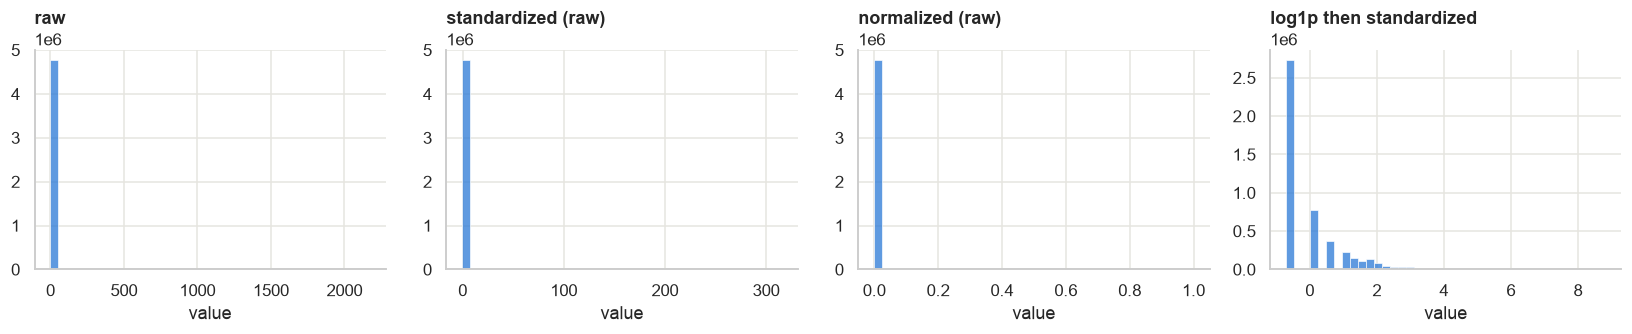

In [11]:
col = ratings["helpful_vote"].to_numpy().reshape(-1, 1).astype(float)
log_col = np.log1p(col)

variants = {
    "raw": col,
    "standardized (raw)": StandardScaler().fit_transform(col),
    "normalized (raw)": MinMaxScaler().fit_transform(col),
    "log1p then standardized": StandardScaler().fit_transform(log_col),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, (name, values) in zip(axes, variants.items()):
    sns.histplot(values.ravel(), bins=40, ax=ax, color=viz.BLUE)
    viz.label(ax, name, "value")
plt.tight_layout()
plt.show()

**Reading the result:** standardizing or normalizing the raw column just relabels the axis —
the shape is still a spike at 0 with a long thin tail, because both transforms are linear and
skew is a non-linear property. `log1p` first compresses the tail into something close to
symmetric, and *then* standardizing gives a genuinely usable numeric feature. This is the
transform used anywhere `helpful_vote`/`text_len` feed a model downstream.

## PCA on the rating-level feature table

**Principal Component Analysis** finds the orthogonal directions (linear combinations of the
original columns) that capture the most variance, in decreasing order. It's a dimensionality
reduction and visualization tool here, not a modeling step — with only 5 numeric features, the
real payoff is seeing whether a 2D projection separates anything meaningful (it also warns us
if two features are redundant enough to drop). Features must be standardized first: PCA finds
directions of maximum variance, so an unscaled column with a huge numeric range would dominate
every component regardless of how informative it actually is.

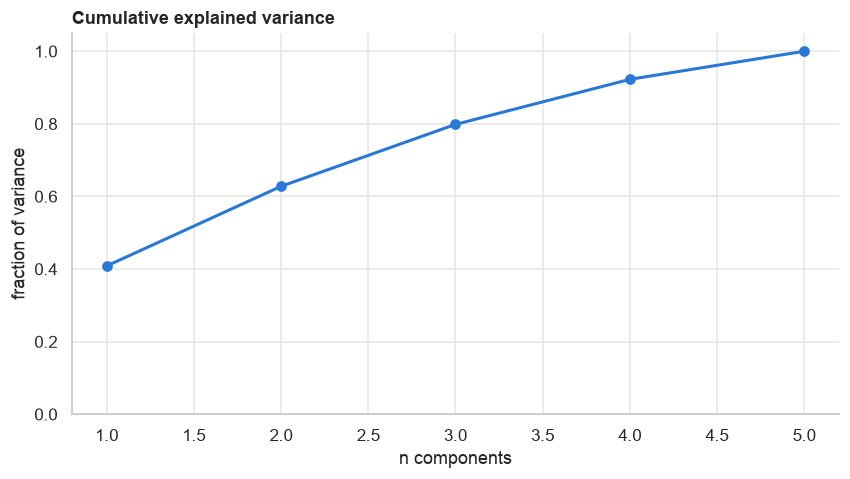

explained variance ratio: [0.409 0.219 0.171 0.124 0.077]


In [12]:
pca_features = features.assign(helpful_vote=np.log1p(features["helpful_vote"]), text_len=np.log1p(features["text_len"])).dropna()
X = StandardScaler().fit_transform(pca_features[["helpful_vote", "text_len", "verified_purchase", "average_rating", "rating_number"]])

pca = PCA(n_components=X.shape[1], random_state=RANDOM_STATE)
pca.fit(X)

ax = viz.new_ax()
ax.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker="o", color=viz.BLUE)
viz.label(ax, "Cumulative explained variance", "n components", "fraction of variance")
ax.set_ylim(0, 1.05)
plt.show()
print("explained variance ratio:", pca.explained_variance_ratio_.round(3))

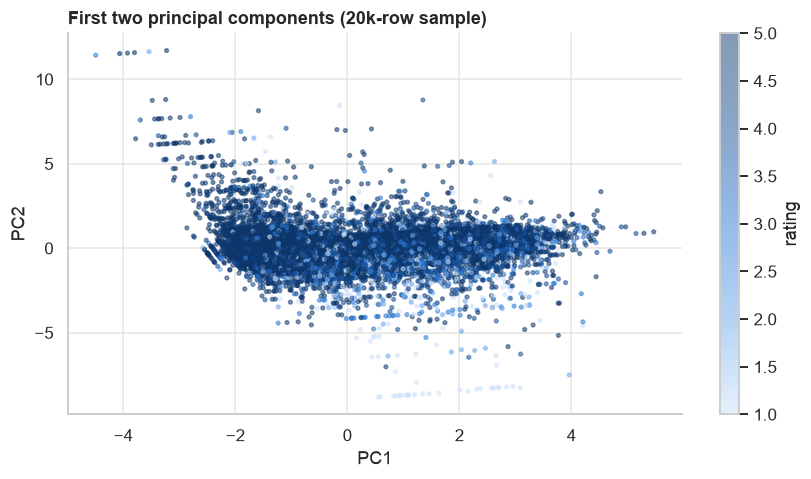

In [13]:
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(pca_features), size=20_000, replace=False)
coords = pca.transform(X)[sample_idx, :2]
colors = pca_features["rating"].to_numpy()[sample_idx]

ax = viz.new_ax()
sc = ax.scatter(coords[:, 0], coords[:, 1], c=colors, cmap=viz.SEQUENTIAL, s=6, alpha=0.5)
plt.colorbar(sc, ax=ax, label="rating")
viz.label(ax, "First two principal components (20k-row sample)", "PC1", "PC2")
plt.show()

**Reading the result:** it takes 3-4 of the 5 components to explain ~90% of the variance —
not much redundancy to prune, these five columns each carry distinct information. The PC1/PC2
scatter shows no clean separation by rating color: engagement metadata (helpful votes, review
length) and album popularity don't linearly predict the star rating a user will give, which
again supports treating "will they interact" (implicit) as the tractable target rather than
"what number will they type" (explicit rating regression).

## Truncated SVD preview on the user-item matrix

PCA needs a dense matrix and needs to center the data (subtract the mean) — neither works for
a user-item interaction matrix with 99.98%+ zeros, centering would destroy the sparsity and
blow up memory. **Truncated SVD** factorizes the sparse matrix directly into
`U @ diag(S) @ V^T` without centering, which is exactly the linear-algebra operation matrix
factorization (notebook 5) learns iteratively — this is a preview of whether that approach has
anything to latch onto, using the most active slice of the data so it's dense enough to be
informative.

sample matrix: (2698, 2905) density: 0.00667199136480264


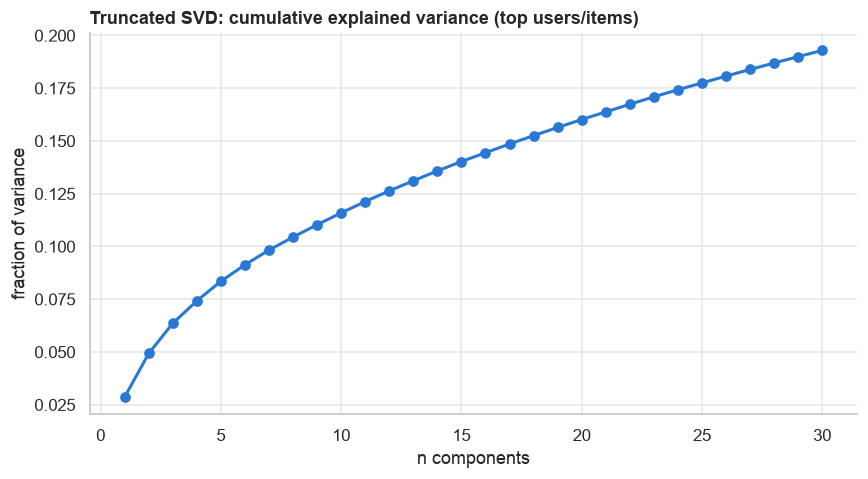

In [14]:
top_users = ratings["user_id"].value_counts().head(3000).index
top_items = ratings["item_id"].value_counts().head(3000).index
sample = ratings[ratings["user_id"].isin(top_users) & ratings["item_id"].isin(top_items)]
matrix, user_index, item_index = build_interaction_matrix(sample)
print("sample matrix:", matrix.shape, "density:", matrix.nnz / (matrix.shape[0] * matrix.shape[1]))

svd = TruncatedSVD(n_components=30, random_state=RANDOM_STATE)
svd.fit(matrix)

ax = viz.new_ax()
ax.plot(np.arange(1, 31), np.cumsum(svd.explained_variance_ratio_), marker="o", color=viz.BLUE)
viz.label(ax, "Truncated SVD: cumulative explained variance (top users/items)", "n components", "fraction of variance")
plt.show()

**Reading the result:** even among the most active users and items — the densest, most
learnable slice of the matrix — the singular values decay slowly: there's no sharp elbow at 2
or 3 components, meaning the interaction patterns aren't explained by a tiny number of latent
tastes. That's a realistic preview for notebook 5: a useful factor model will likely need
dozens of latent factors, not a handful, and we shouldn't expect a low-rank model to compress
this into something visually tidy in 2D the way the PCA scatter above did.

## Handing off

`ratings` here has deduplicated (user_id, item_id) pairs (keeping the latest edit). Every
later notebook loads straight from `data/processed/ratings.parquet` and re-applies the same
dedup via `groovn.data.load_ratings` + `drop_duplicates`, rather than depending on an
in-memory variable from this notebook — so this cell is just confirming the hand-off contract,
not writing a new file.

In [15]:
assert ratings.duplicated(subset=["user_id", "item_id"]).sum() == 0
print(f"final ratings for downstream notebooks: {len(ratings):,} rows, "
      f"{ratings['user_id'].nunique():,} users, {ratings['item_id'].nunique():,} items")

final ratings for downstream notebooks: 4,772,071 rows, 1,754,118 users, 701,673 items
